In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.manifolds.euclidean.vector.pullback.standard.banana import BananaStandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.standard import StandardVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.k_fold import KfoldVectorRiemannianAutoencoder

# set font size for plots
plt.rcParams.update({'font.size': 20})

# manual seed
torch.manual_seed(31)

In [2]:
vector_euclidean = BananaStandardPullbackVectorEuclidean(shear=0.1, offset=2.0)

base_point = torch.zeros((2,)) # shape (2,)
tangent_basis = F.normalize(torch.randn((2,)), dim=0)[None]  # shape (1, 2)

standard_rae = StandardVectorRiemannianAutoencoder(vector_euclidean, base_point, tangent_basis)
kfold_rae = KfoldVectorRiemannianAutoencoder(vector_euclidean, base_point, tangent_basis, K=10, step_size=0.5)

In [3]:
# project some data on the manifold
data = torch.randn((100, 2)) * 4.0

# standard RAE
print("Computing standard RAE projections...")
rae_projected_data = standard_rae.project_on_manifold(data)
rae_sq_errors = ((rae_projected_data - data) ** 2).sum(-1)
rae_rmse = torch.sqrt(torch.mean(rae_sq_errors))

# k-fold RAE
print("Computing k-fold RAE projections...")
kfold_rae_projected_data = kfold_rae.project_on_manifold(data)
kfold_rae_sq_errors = ((kfold_rae_projected_data - data) ** 2).sum(-1)
kfold_rae_rmse = torch.sqrt(torch.mean(kfold_rae_sq_errors))

Computing standard RAE projections...
Computing k-fold RAE projections...


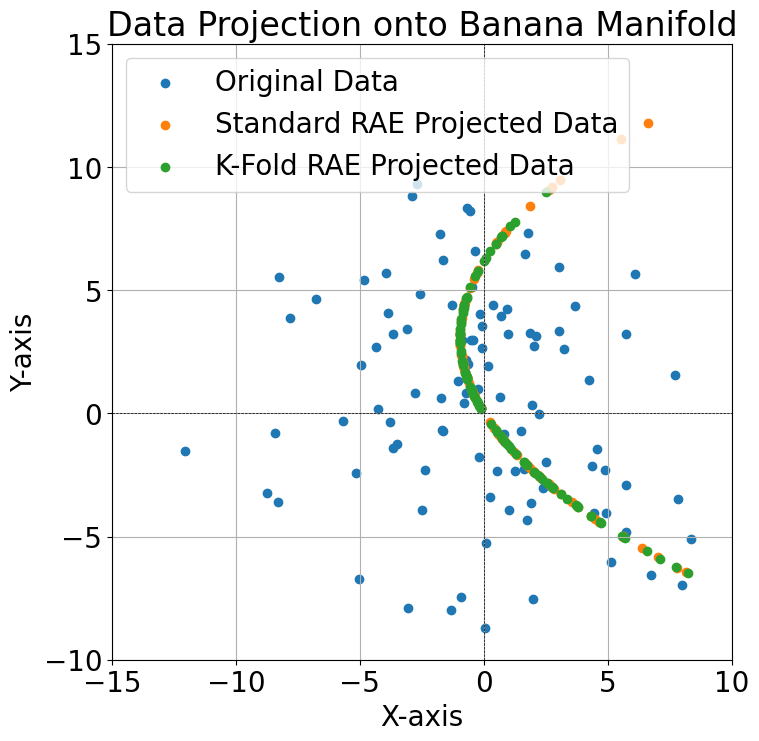

In [4]:
# plot results
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.scatter(rae_projected_data[:, 0], rae_projected_data[:, 1], label='Standard RAE Projected Data')
plt.scatter(kfold_rae_projected_data[:, 0], kfold_rae_projected_data[:, 1], label='K-Fold RAE Projected Data')
plt.title('Data Projection onto Banana Manifold')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.xlim(-15, 10)
plt.ylim(-10, 15)
plt.grid()
plt.legend()
plt.show()

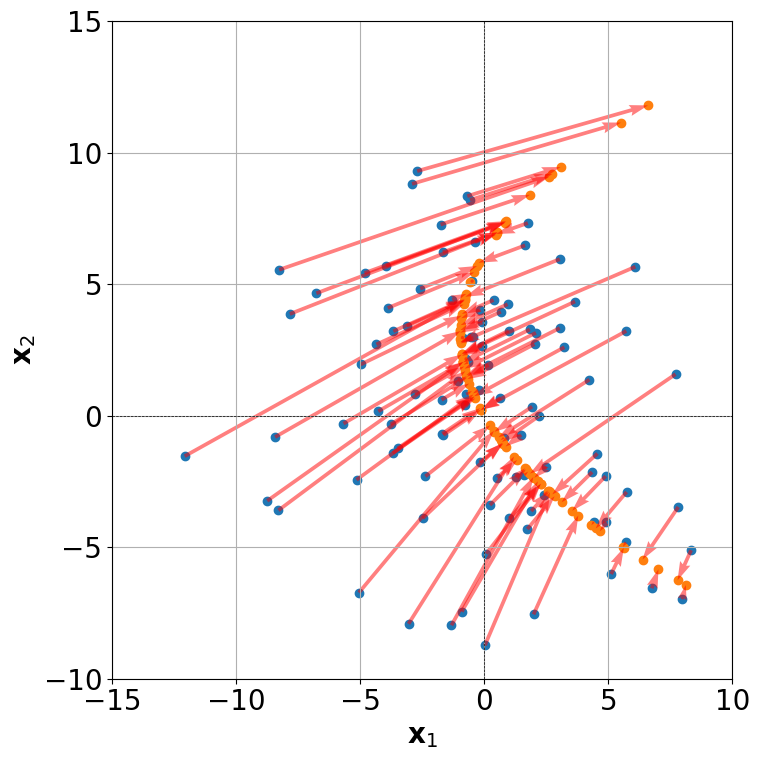

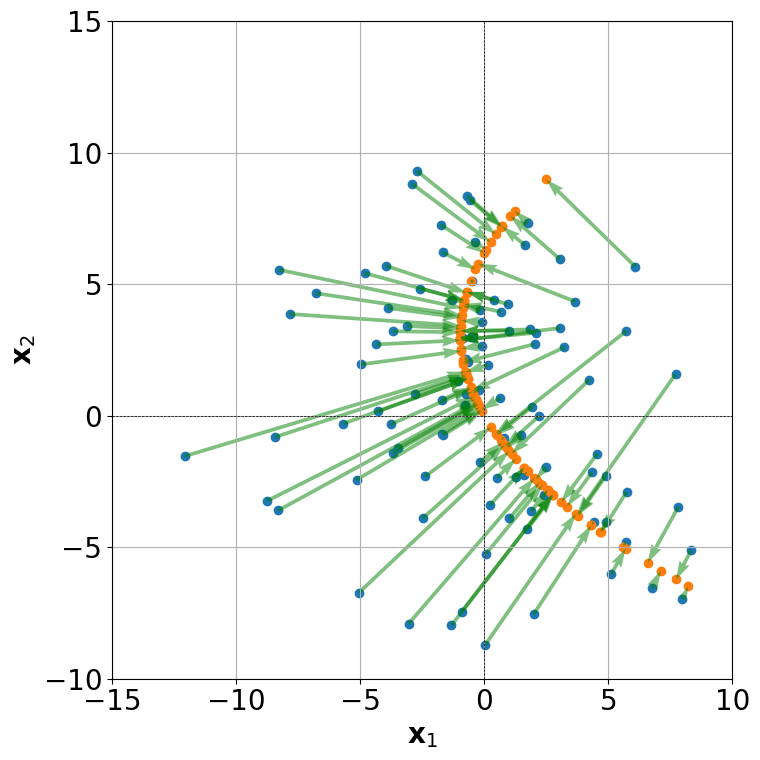

In [5]:
# make sure that both plots have same limits
# make quiver plot where arrows go from data to projected data
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.scatter(rae_projected_data[:, 0], rae_projected_data[:, 1], label='Standard RAE Projected Data')
plt.quiver(data[:, 0], data[:, 1],
           rae_projected_data[:, 0] - data[:, 0],
           rae_projected_data[:, 1] - data[:, 1],
           angles='xy', scale_units='xy', scale=1, color='r', alpha=0.5, label='Standard RAE Projection Arrows')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.xlim(-15, 10)
plt.ylim(-10, 15)
plt.grid()
plt.tight_layout()
plt.savefig('./results/banana/rae_projection_quiver.png')
plt.show()

# make same plot for only the k_fold RAE
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.scatter(kfold_rae_projected_data[:, 0], kfold_rae_projected_data[:, 1], label='K-Fold RAE Projected Data')
plt.quiver(data[:, 0], data[:, 1],
           kfold_rae_projected_data[:, 0] - data[:, 0],
           kfold_rae_projected_data[:, 1] - data[:, 1],
           angles='xy', scale_units='xy', scale=1, color='g', alpha=0.5, label='K-Fold RAE Projection Arrows')      
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.xlim(-15, 10)
plt.ylim(-10, 15)
plt.grid()
plt.tight_layout()
plt.savefig('./results/banana/kfold_rae_projection_quiver.png')
plt.show()

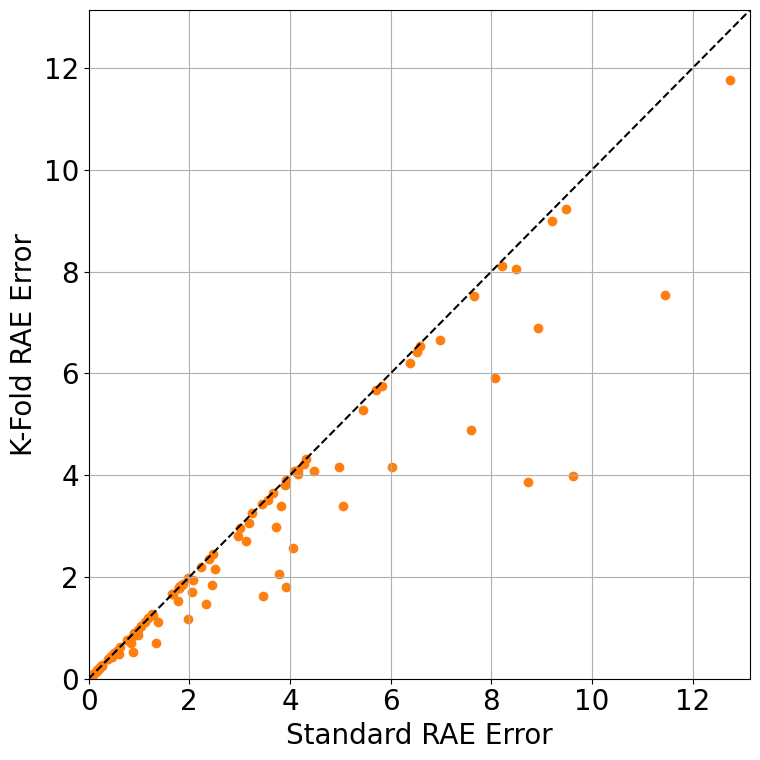

In [10]:
# for each data point, make scatter plot of rae error vs kfold rae error
max_error = max(rae_sq_errors.sqrt().max(), kfold_rae_sq_errors.sqrt().max())+0.4

plt.figure(figsize=(8, 8))
plt.scatter(rae_sq_errors.sqrt(), kfold_rae_sq_errors.sqrt(), c='C1')
plt.plot([0, max_error], [0, max_error], color='k', linestyle='--', label='y=x line')
plt.xlabel('Standard RAE Error')
plt.ylabel('K-Fold RAE Error')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.xlim(0, max_error)
plt.ylim(0, max_error)
plt.grid()
plt.tight_layout()
plt.savefig('results/banana/rae_vs_kfold_rae_error.png')
plt.show()